### practical 13

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [24]:
iris = sns.load_dataset('iris')

In [26]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [28]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


array([[<Axes: title={'center': 'sepal_length'}>,
        <Axes: title={'center': 'sepal_width'}>],
       [<Axes: title={'center': 'petal_length'}>,
        <Axes: title={'center': 'petal_width'}>]], dtype=object)

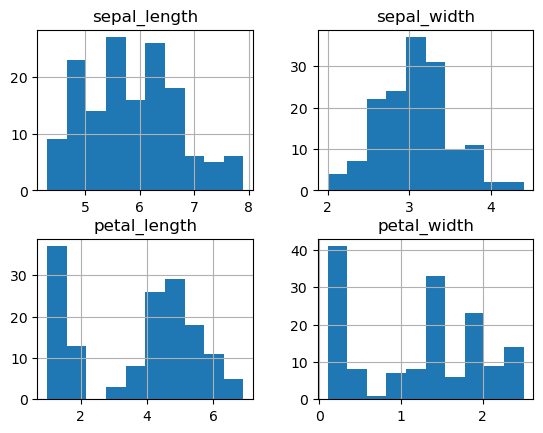

In [36]:
iris.hist()

In [102]:
def scan_outliers(df,col):
    Q1= df[col].quantile(0.25)
    Q3= df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    if len(outliers) == 0:
        return f"No outliers found in '{col}'"
    else:
        return f"Outliers found in {col} :- {outliers[col].values} "

print(scan_outliers(iris, 'sepal_length'))
print(scan_outliers(iris, 'sepal_width'))
print(scan_outliers(iris, 'petal_width'))
print(scan_outliers(iris, 'petal_length'))

No outliers found in 'sepal_length'
Outliers found in sepal_width :- [4.4 4.1 4.2 2. ] 
No outliers found in 'petal_width'
No outliers found in 'petal_length'


In [104]:
def remove_outliers(df,col):
    Q1= df[col].quantile(0.25)
    Q3= df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    removed = df[(df[col] >= lower) | (df[col] <= upper)]
    return removed
    
print(remove_outliers(iris, 'sepal_length'))
print(remove_outliers(iris, 'sepal_width'))
print(remove_outliers(iris, 'petal_width'))
print(remove_outliers(iris, 'petal_length'))

     sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]
     sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1         

In [130]:
import numpy as np
iris_num = iris.select_dtypes(include='number').columns
print(iris_num)
skew_data = []
for iris_data in iris_num:
    skew_data.append(iris[iris_data].skew())
print(skew_data)    

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')
[0.3149109566369728, 0.31896566471359966, -0.27488417975101276, -0.10296674764898116]


Skewness of Marks column: -0.27


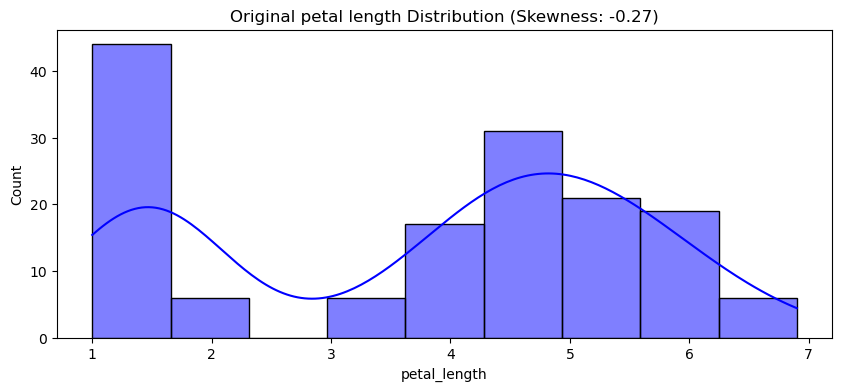

In [138]:
iris_petal_length_skew = skew_data[2]
print(f"Skewness of Marks column: {iris_petal_length_skew:.2f}")


plt.figure(figsize=(10, 4))
sns.histplot(iris['petal_length'], kde=True, color='blue')
plt.title(f"Original petal length Distribution (Skewness: {iris_petal_length_skew:.2f})")
plt.show()

In [150]:
iris['iris_petal_length_Transformed'] = np.cbrt(iris['petal_length'])
transformed_skew = iris['iris_petal_length_Transformed'].skew()
print(f"Skewness after Log Transformation: {transformed_skew:.2f}")

Skewness after Log Transformation: -0.50


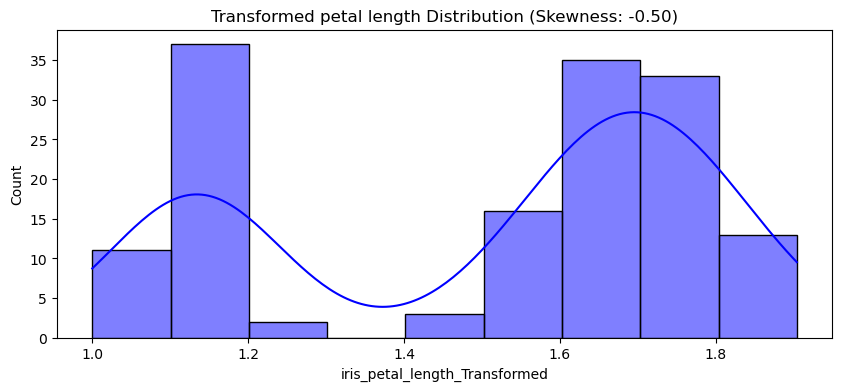

In [152]:
plt.figure(figsize=(10, 4))
sns.histplot(iris['iris_petal_length_Transformed'], kde=True, color='blue')
plt.title(f"Transformed petal length Distribution (Skewness: {transformed_skew :.2f})")
plt.show()

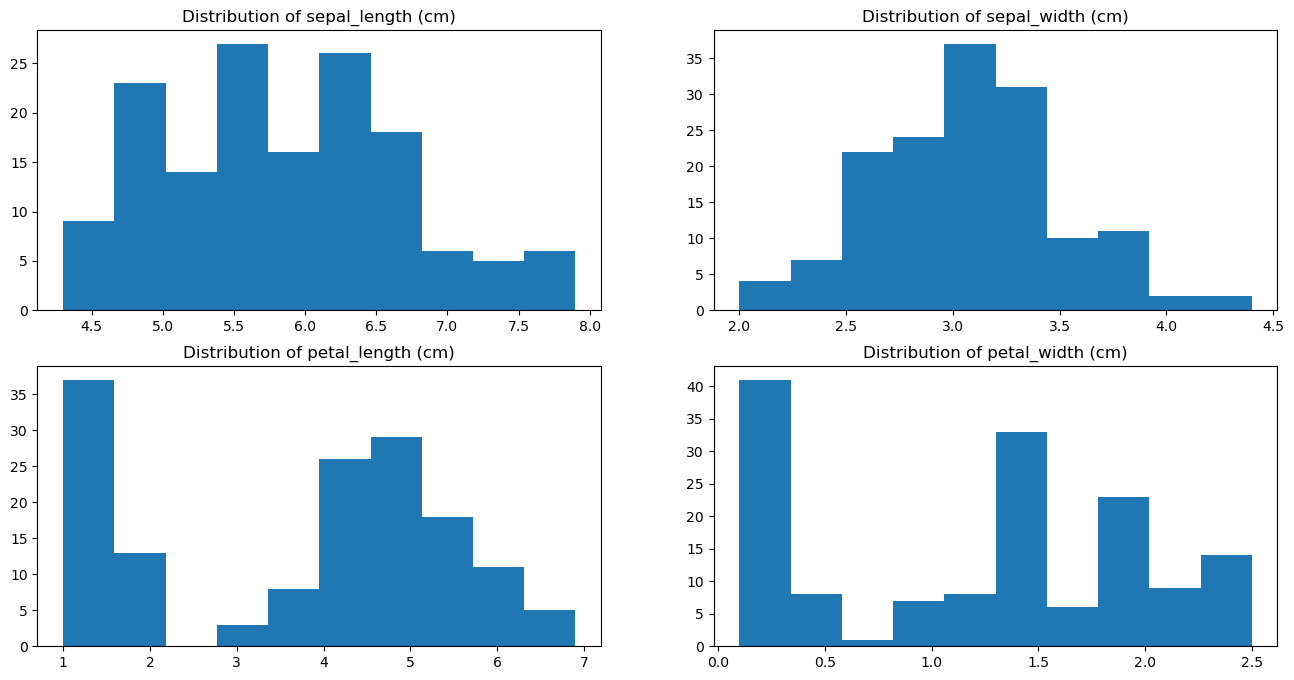

In [48]:
fig,axes = plt.subplots(2,2,figsize=(16,8))
axes[0,0].set_title("Distribution of sepal_length (cm)")
axes[0,0].hist(iris["sepal_length"]);
axes[0,1].set_title("Distribution of sepal_width (cm)")
axes[0,1].hist(iris["sepal_width"]);
axes[1,0].set_title("Distribution of petal_length (cm)")
axes[1,0].hist(iris["petal_length"]);
axes[1,1].set_title("Distribution of petal_width (cm)")
axes[1,1].hist(iris["petal_width"]);


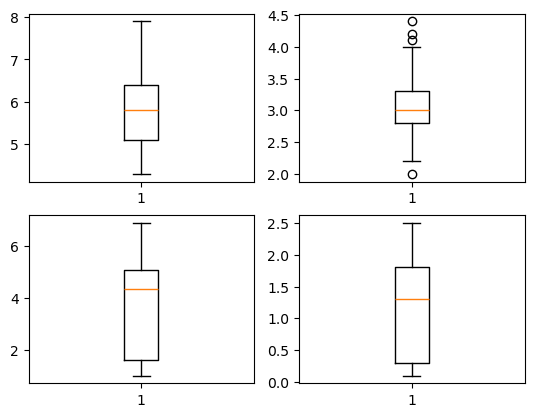

In [52]:
fig = plt.figure(1,figure = (12,8))

ax_1 = fig.add_subplot(221)
ax_2 = fig.add_subplot(222)
ax_3 = fig.add_subplot(223)
ax_4 = fig.add_subplot(224)

bp = ax_1.boxplot(iris["sepal_length"])
bp = ax_2.boxplot(iris["sepal_width"])
bp = ax_3.boxplot(iris["petal_length"])
bp = ax_4.boxplot(iris["petal_width"])

In [ ]:
### practical 12